<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Transformers_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
import pandas as pd
import torchvision.transforms as T
from torchsummary import summary

In [2]:
# connect to the drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [3]:
dataset_path = "2750"
device  = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
!unzip "/content/drive/MyDrive/Big Img Sig/Transformers/EuroSAT.zip"

In [5]:
for dirpath, dirnames, filenames in os.walk(dataset_path):
  print(f'There are {len(dirnames)} directories and {len(filenames)} files in [{dirpath}]')

There are 10 directories and 0 files in [2750]
There are 0 directories and 3000 files in [2750/HerbaceousVegetation]
There are 0 directories and 3000 files in [2750/SeaLake]
There are 0 directories and 2500 files in [2750/Highway]
There are 0 directories and 2500 files in [2750/River]
There are 0 directories and 2500 files in [2750/Industrial]
There are 0 directories and 2000 files in [2750/Pasture]
There are 0 directories and 3000 files in [2750/Forest]
There are 0 directories and 3000 files in [2750/AnnualCrop]
There are 0 directories and 2500 files in [2750/PermanentCrop]
There are 0 directories and 3000 files in [2750/Residential]


In [6]:
# get all classes
classes = os.listdir(dataset_path)
labels = {
  'PermanentCrop': 0,
  'Industrial':1,
  'AnnualCrop': 2,
  'Highway': 3,
  'Forest': 4,
  'Residential': 5,
  'Pasture': 6,
  'River': 7,
  'SeaLake': 8,
  'HerbaceousVegetation': 9,
}
labels

{'PermanentCrop': 0,
 'Industrial': 1,
 'AnnualCrop': 2,
 'Highway': 3,
 'Forest': 4,
 'Residential': 5,
 'Pasture': 6,
 'River': 7,
 'SeaLake': 8,
 'HerbaceousVegetation': 9}

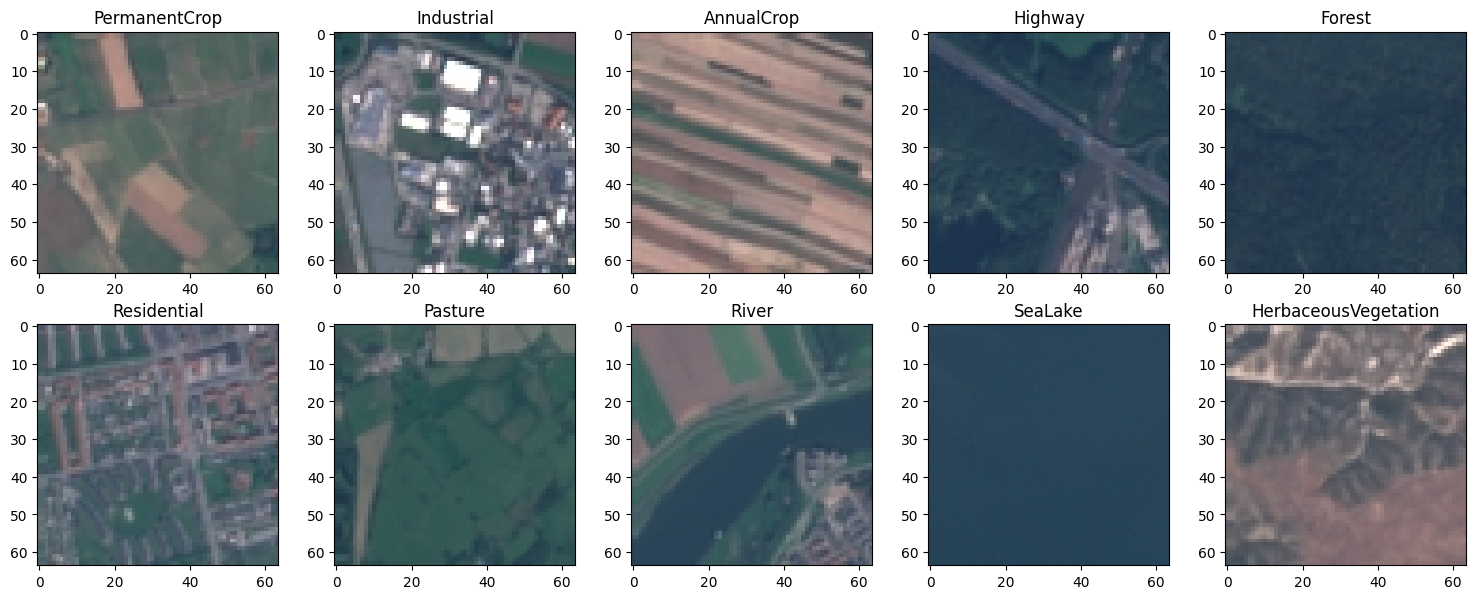

In [ ]:
# plot a random image from each class
plt.figure(figsize=(15, 6))
for i in range(10):
  cls = classes[i]
  imgs = os.listdir(f'{dataset_path}/{cls}')
  rand_idx = np.random.randint(len(imgs))
  img = mpimg.imread(f'{dataset_path}/{cls}/{imgs[rand_idx]}')
  plt.subplot(2, 5, i+1)
  plt.imshow(img)
  plt.title(cls)

plt.tight_layout()

In [7]:
# split the dataset
train_data, val_data, test_data = [], [], []
train_count, val_count, test_count = [], [], []
tr_per = 0.7
val_per = 0.2
for i, cls in enumerate(classes):
  imgs = os.listdir(f'{dataset_path}/{cls}')
  np.random.shuffle(imgs)
  tr_point = int(np.round(len(imgs)*tr_per))
  val_point = tr_point + int(np.round(len(imgs)*val_per))
  train_data.extend(imgs[:tr_point])
  train_count.append(len(imgs[:tr_point]))
  val_data.extend(imgs[tr_point: val_point])
  val_count.append(len(imgs[tr_point: val_point]))
  test_data.extend(imgs[val_point:])
  test_count.append(len(imgs[val_point:]))

In [8]:
np.array(train_data), np.array(val_data), np.array(test_data)
len(train_data), len(val_data), len(test_data)

(18900, 5400, 2700)

/tmp/ipykernel_1487/2700707204.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(classes, rotation=45, ha='right')
/tmp/ipykernel_1487/2700707204.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(classes, rotation=45, ha='right')
/tmp/ipykernel_1487/2700707204.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(classes, rotation=45, ha='right')


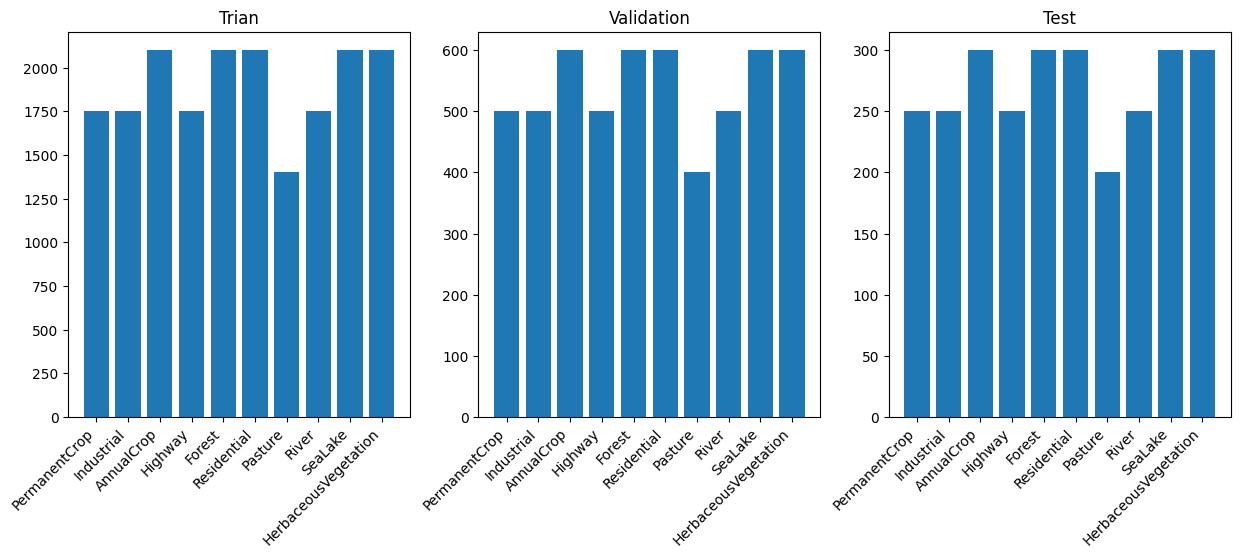

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot the training validation and testing destribution split
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].bar(classes, train_count)
ax[0].set_xticklabels(classes, rotation=45, ha='right')
ax[0].set_title("Trian")

ax[1].bar(classes, val_count)
ax[1].set_xticklabels(classes, rotation=45, ha='right')
ax[1].set_title("Validation")


ax[2].bar(classes, test_count)
ax[2].set_xticklabels(classes, rotation=45, ha='right')
ax[2].set_title("Test")
plt.show()
plt.tight_layout()

In [57]:
# Get the dataset
class Dataset(torch.utils.data.Dataset):
  def __init__(self, img_list, transfor=None):
    self.img_list = img_list
    self.transfor = transfor
  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, index):
    img_path = self.img_list[index]
    img_dir = img_path.split('_')[0]
    img_path = os.path.join(dataset_path,img_dir, img_path)
    img = Image.open(img_path)
    # img = np.array(img)
    if self.transfor:
      img = self.transfor(img)
    return img, labels[img_dir]

IMAGE_SIZE = 64

In [58]:
# Get the mean and std of feature images
transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # keep consistent size
    T.ToTensor()
])

dataset = Dataset(train_data, transfor=transform)

loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

mean = 0.
std = 0.
total_images = 0

for images, _ in loader:
    batch_size = images.size(0)
    images = images.view(batch_size, images.size(1), -1)  # flatten H,W

    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)

    total_images += batch_size

mean /= total_images
std /= total_images

print("Mean:", mean)
print("Std:", std)


Mean: tensor([0.3435, 0.3797, 0.4074])
Std: tensor([0.0912, 0.0649, 0.0551])


In [59]:
train_data_mean = [0.3435, 0.3797, 0.4074]
train_data_std = [0.0912, 0.0649, 0.0551]


transform_train = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    # T.RandomHorizontalFlip(p=0.5),

    # very light augmentation
    # T.RandomRotation(10),   # smaller than affine
    # T.ColorJitter(brightness=0.1, contrast=0.1),

    T.ToTensor(),
    T.Normalize(mean=train_data_mean, std=train_data_std),
])


transform_test = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=train_data_mean, std=train_data_std),
    ])

In [60]:
# fetch the dataset
train_dataset = Dataset(train_data, transfor=transform_train)
val_dataset = Dataset(val_data, transfor=transform_test)
test_dataset = Dataset(test_data, transfor=transform_test)
len(train_dataset), len(val_dataset), len(test_dataset)

(18900, 5400, 2700)

In [61]:
# Load the dataset
train_data_loader = torch.utils.data.DataLoader(train_dataset,
                                                batch_size=64,
                                                shuffle=True,
                                                num_workers=2,
                                                drop_last=True, pin_memory=True)
val_data_loader = torch.utils.data.DataLoader(val_dataset,
                                                batch_size=64,
                                                shuffle=True,
                                                num_workers=2,
                                                drop_last=False, pin_memory=True)
test_data_loader = torch.utils.data.DataLoader(test_dataset,
                                                batch_size=64,
                                                shuffle=False,
                                                num_workers=2,
                                                drop_last=False, pin_memory=True)
print('Number of batches for each train, val, test data loader')
len(train_data_loader), len(val_data_loader), len(test_data_loader)

Number of batches for each train, val, test data loader


(295, 85, 43)

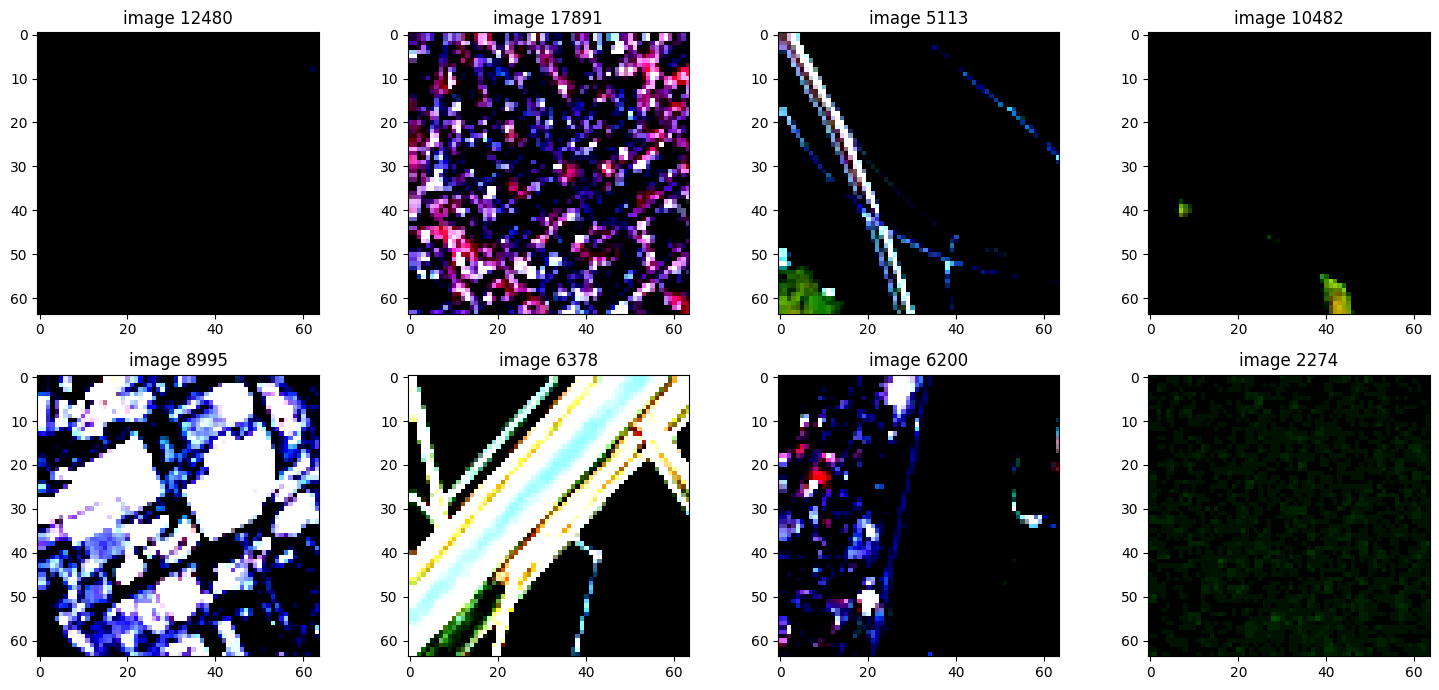

In [62]:
# plot some augmented images
plt.figure(figsize=(15, 7))
for i in range(8):
  idx = np.random.randint(0, len(train_data_loader.dataset))
  img, label = train_data_loader.dataset.__getitem__(idx)

  img = img.permute(1,2,0).cpu().numpy()

  plt.subplot(2, 4, i+1)
  plt.imshow(img)
  plt.title(f"image {idx}")
plt.tight_layout()

Link: https://medium.com/@bskkim2022/paper-reimplementation-vit-vision-transformer-eed3ad20dfe7

**Patch embedding** & **Positional embedding**

In [64]:
class ViTEmbedding(nn.Module):
  def __init__(self, image_size, in_channels, patch_size, embed_dim):
    super(ViTEmbedding, self).__init__()
    self.num_patches = (image_size // patch_size)**2
    self.patch_embedding = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    self.cls_token = nn.Parameter(torch.zeros(1,1, embed_dim))
    self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches+1, embed_dim))
  def forward(self, x):
    B = x.shape[0]
    x = self.patch_embedding(x) # (B, D, H/P, W/P)
    x = x.flatten(2) # (B, D, H/P*W/P)
    x = x.transpose(1, 2)
    cls_token = self.cls_token.expand(B, -1, -1) #  (B, 1, D)
    x = torch.cat((cls_token, x), dim=1 ) # (B, N+1, D) Concatinate CLS token at the beginning
    x = x + self.pos_embed # possitional encoding
    return x # (B, N+1, D)

# # testin
# patch_size = 4
# num_channels = 3
# img_size = 224
# in_channels = 3
# num_dim = 768
# dumy = torch.randn(patch_size, num_channels, img_size, img_size)
# patch_embedding = ViTEmbedding(img_size, in_channels, patch_size, num_dim)
# response = patch_embedding(dumy)

**Multi Head Self Attention Class**

In [70]:
class MultiHeadAttention(nn.Module):
  def __init__(self, embed_dim=768, num_heads=8):
    super().__init__()
    self.embed_dim = embed_dim
    self.num_heads = num_heads
    self.head_dim = embed_dim//num_heads
    assert(
        self.num_heads * self.head_dim == embed_dim
    ), "embed_dim must be devisible by num_heads"

    self.qkv_projection = nn.Linear(in_features=self.embed_dim, out_features=self.embed_dim*3)
    self.out_projection = nn.Linear(in_features=embed_dim, out_features=embed_dim)

  def forward(self, x, return_attention=False):
    B, N, D = x.shape # (B, N+1, D) --> N = H/P * W/P
    # print(f'x: {x.shape}')
    qkv = self.qkv_projection(x) # (B, N+1, 3*D)
    # print(f'qkv: {qkv.shape}')
    qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim) # (B, N=1, 3, H, D/H)
    # print(f'qkv after reshape: {qkv.shape}')
    q = qkv[:, :, 0].transpose(1, 2)  # (B, H, N, D/H)
    k = qkv[:, :, 1].transpose(1, 2)
    v = qkv[:, :, 2].transpose(1, 2)
    # print(f'q: {q.shape}, k: {k.shape}, v: {v.shape}')
    attn_scores = torch.einsum('bhnd,bhmd->bhnm', q / (self.head_dim**0.5), k) # (B, H, N+1, N+1)
    # print(f'attn_scores: {attn_scores.shape}, head_dim: {self.head_dim}')
    attn_weights = torch.softmax(attn_scores, dim=-1) # (B, H, N+1, N+1)
    # print(f'attn_weights: {attn_weights.shape}')
    attn_output = torch.einsum('bhnm,bhmd->bhnd', attn_weights, v) # (B, H, N+1, D/H)
    attn_output = attn_output.transpose(1, 2).reshape(B, N, D)  # (B, H, N+1, D/H) --> (B, N+1, H, D/H) --> (B, N+1, D)
    # print(f"attn_output: {attn_output.shape}")

    if return_attention:
      return self.out_projection(attn_output), attn_weights

    return self.out_projection(attn_output)

# test_attention = MultiHeadAttention(768, 12)
# dummy_dataset = torch.randn(2, 196, 768)
# # dummy_dataset.shape
# pred = test_attention(dummy_dataset)
# pred.shape

**Transforemr Encoder Class**

The encoder consists of two main components:
* **MSA:**
> The input embeddings are first layer-normalized, then pass through MSA. Then, skip connection occurs by adding the original embeddings to the MSA output.

* **MLP:**
> The result is again passed through layer normaization and fed into the MLP. Another skip connection adds the original result to the MLP output.
*This final output of a transformer encoder is passed through subsequently multiple transformer encoders as many times as B, which is the number of transformer encoder blocks.*

In [71]:
class TransformerEncoder(nn.Module):
  def __init__(self, embed_dim):
    super().__init__()
    self.norm1 = nn.LayerNorm(normalized_shape=embed_dim) # Normalize layer for MSA
    self.norm2 = nn.LayerNorm(normalized_shape=embed_dim) # Normalize layer for MLP

    self.MSA = MultiHeadAttention(embed_dim=embed_dim)
    self.MLP = nn.Sequential(
        nn.Linear(embed_dim, embed_dim*4),
        nn.GELU(),
        nn.Linear(embed_dim*4, embed_dim)
    )

  def forward(self, x):
    x = x + self.MSA(self.norm1(x)) # (B, N+1, D)
    x = x + self.MLP(self.norm2(x)) # (B, N+1, D)
    return x

**Full ViT Transformers Class**
> ViT Transformer Class = Embedding class: (1) + Transformer Encoder class: (2) + (3) + Final MLP that predicts classes

> Input (3,H,W) → Embedding Class → (N+1, D) → B times Transformer Encoder Class → (N+1, D) → MLP → (C), where C is the number of classes

In [72]:
class ViTTransformers(nn.Module):
  def __init__(self, num_classes=10,
               block_num=2,
               img_size=224,
               path_size=4,
               in_channels=3,
               embed_dim=12):
    super().__init__()

    self.embedding = ViTEmbedding(img_size, in_channels, path_size, embed_dim)
    self.encoder_layer = nn.ModuleList(
        [
          TransformerEncoder(embed_dim)  for _ in range(block_num)
        ]
    )
    self.classifier = nn.Linear(embed_dim, num_classes)

  def forward(self, x):
    x = self.embedding(x) # (B, N+1, D)
    for encoder in self.encoder_layer:
      x = encoder(x)
    cls_token = x[:, 0] # extract cls token
    return self.classifier(cls_token) # (B, num_classes)

model_0 = ViTTransformers(num_classes=len(classes),
                          img_size=IMAGE_SIZE,
                          block_num=4,
                          embed_dim=128).to(device)
model_0

ViTTransformers(
  (embedding): ViTEmbedding(
    (patch_embedding): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder_layer): ModuleList(
    (0-3): 4 x TransformerEncoder(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (MSA): MultiHeadAttention(
        (qkv_projection): Linear(in_features=128, out_features=384, bias=True)
        (out_projection): Linear(in_features=128, out_features=128, bias=True)
      )
      (MLP): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
      )
    )
  )
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)

**Setpup for Training:**
1. Loss function: As it is multi-class classification problem, Cross entropy loss is used
2. Optimizer: Following the original paper, Adam optimizer is used and a base learning rate of 0.0003 is adopted, reflecting the paper’s recommendation and empirical tuning.
3. Scheduler: Training is conducted for 60 epochs, with the learning rate scaled with a factor of 0.1 every 20 epochs.


In [73]:
loss_fun = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001) #, weight_decay=1e-1)
schedular = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20*i for i in range(1,3)], gamma=0.1)

**Training**

In [74]:
def train_model(model, dataloader, loss_fun, optimizer):
  model.train()
  train_loss, train_acc = 0, 0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    optimizer.zero_grad() # reset all the gradient
    row_score = model(X) # logits
    loss = loss_fun(row_score, y)
    train_loss += loss.item()

    loss.backward() # compute the gradient
    optimizer.step() # update the weights

    # Calculate and accumulate accuracy metric across all batches
    y_pred_class = torch.argmax(row_score, dim=1)
    tr_acc = (y_pred_class == y).sum().item()/len(row_score)
    train_acc += tr_acc
    # if batch % 200 == 0 and batch > 0:
    #   print(f"Batch {batch}: Train Loss: {loss.item():.4f}, Train Accuracy: {tr_acc:.4f}")
    #   break

    # Adjust metrics to get average loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc


In [75]:
def validate_model(model, dataloader, loss_fun):
  model.eval()
  validation_acc, validation_loss = 0, 0
  with torch.no_grad(): # disable the grad calculation
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      pred = model(X)
      loss = loss_fun(pred, y)
      validation_loss += loss.item()
      y_pred_class = torch.argmax(pred, dim=1)
      val_acc = (y_pred_class == y).sum().item()/len(pred)
      validation_acc += val_acc
      # if batch % 10 == 0 and batch > 0:
      #   break

  validation_loss = validation_loss / len(dataloader)
  validation_acc = validation_acc / len(dataloader)
  return validation_loss, validation_acc

In [76]:
epoch = 15
history = {
    "tr_loss": [],
    "tr_acc": [],
    "val_loss": [],
    "val_acc": []
}
previous_lr = optimizer.param_groups[0]['lr']
for i in range(epoch):
  tr_loss, tr_acc = train_model(model_0, train_data_loader, loss_fun, optimizer)
  history['tr_acc'].append(tr_acc)
  history['tr_loss'].append(tr_loss)
  val_loss, val_acc = validate_model(model_0, val_data_loader, loss_fun)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)
  print(f"Epoch {i+1}: Train Loss: {tr_loss:.4f}, Train Accuracy: {tr_acc:.4f}")
  print(f"\t Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")
  # update the learning rate
  # schedular.step(round(val_loss, 4)) # <-- reduces noise sensitivity
  if schedular:
    schedular.step()
    current_lr = optimizer.param_groups[0]['lr']
    if current_lr != previous_lr:
      print(f"[Epoch {epoch+1}] Learning rate changed to: {current_lr:.6f}")
      previous_lr = current_lr


Epoch 1: Train Loss: 0.9005, Train Accuracy: 0.6784
	 Val Loss: 0.5815, Val Accuracy: 0.7837
Epoch 2: Train Loss: 0.5122, Train Accuracy: 0.8180
	 Val Loss: 0.4685, Val Accuracy: 0.8385
Epoch 3: Train Loss: 0.3881, Train Accuracy: 0.8631
	 Val Loss: 0.3639, Val Accuracy: 0.8702
Epoch 4: Train Loss: 0.3321, Train Accuracy: 0.8799
	 Val Loss: 0.3549, Val Accuracy: 0.8759
Epoch 5: Train Loss: 0.2752, Train Accuracy: 0.9040
	 Val Loss: 0.3331, Val Accuracy: 0.8843
Epoch 6: Train Loss: 0.2238, Train Accuracy: 0.9207
	 Val Loss: 0.2964, Val Accuracy: 0.8999
Epoch 7: Train Loss: 0.2061, Train Accuracy: 0.9253
	 Val Loss: 0.3040, Val Accuracy: 0.9006
Epoch 8: Train Loss: 0.1780, Train Accuracy: 0.9364
	 Val Loss: 0.2990, Val Accuracy: 0.9013
Epoch 9: Train Loss: 0.1636, Train Accuracy: 0.9419
	 Val Loss: 0.3493, Val Accuracy: 0.8802
Epoch 10: Train Loss: 0.1429, Train Accuracy: 0.9481
	 Val Loss: 0.3377, Val Accuracy: 0.8937
Epoch 11: Train Loss: 0.1129, Train Accuracy: 0.9619
	 Val Loss: 0.34

<Axes: >

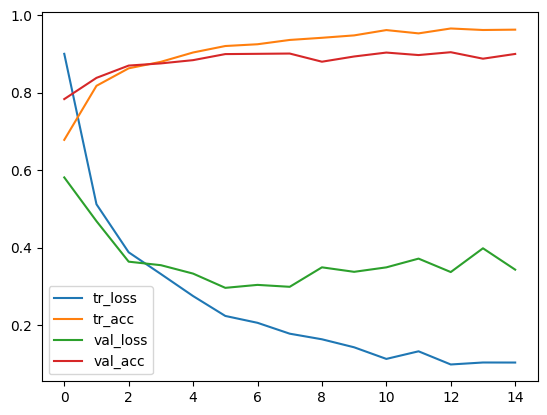

In [77]:
# plot the los curve
pd.DataFrame(history).plot()